## Data Visualization with Python

Seaborn built-in datasets:
https://www.kaggle.com/datasets/abdoomoh/all-seaborn-built-in-datasets

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Set theme by seaborn

In [181]:
sns.set_theme(style="whitegrid")

### Bar Chart

A bar chart is a statistical visualization used to represent categorical data using rectangular bars.
Each bar represents a value (or group of values), and its height or length indicates the magnitude.
Two types or bar chart:
- Vertical (Direct) Bar Plot: Data is represented using vertical columns

- Horizontal Bar Plot: Data is represented using horizontal columns.

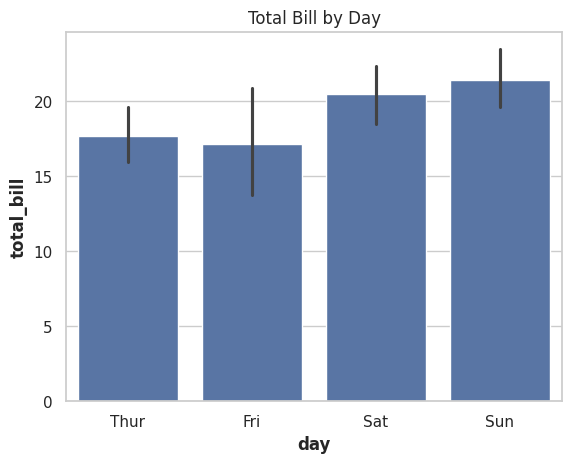

In [182]:
# Bar Chart
tips = sns.load_dataset("tips")

plt.title("Total Bill by Day")
sns.barplot(x="day", y="total_bill", data=tips)
plt.show()

/tmp/ipython-input-1502565642.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="total_bill", data=tips,


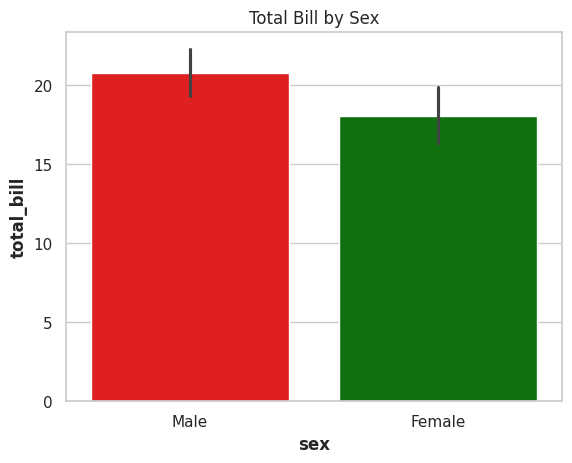

In [183]:
# Bar Chart that compares Female and Male total bills
# Red and Green color
tips = sns.load_dataset("tips")

plt.title("Total Bill by Sex")
sns.barplot(x="sex", y="total_bill", data=tips,
            palette=["red", "green"])
plt.show()

/tmp/ipython-input-1617462927.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="pulse", y="kind", data=exercies, orient='h',


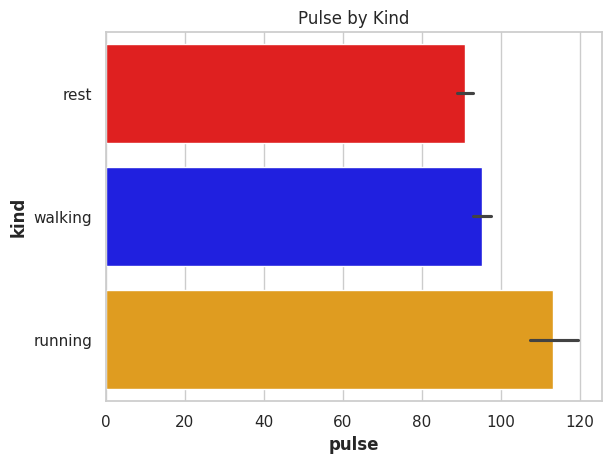

In [184]:
# Load the exercises dataset
exercies = sns.load_dataset("exercise")

plt.title("Pulse by Kind")
sns.barplot(x="pulse", y="kind", data=exercies, orient='h',
            palette=['red', 'blue', 'orange'])
plt.show()

### Clustered Bar Chart

A clustered bar plot displays multiple bars side-by-side for each category, representing different groups or sub-categories.
- Each cluster corresponds to a main category, while individual bars within the cluster represent separate data series.
- It enables simultaneous comparison across categories and sub-categories, making group differences easy to observe.

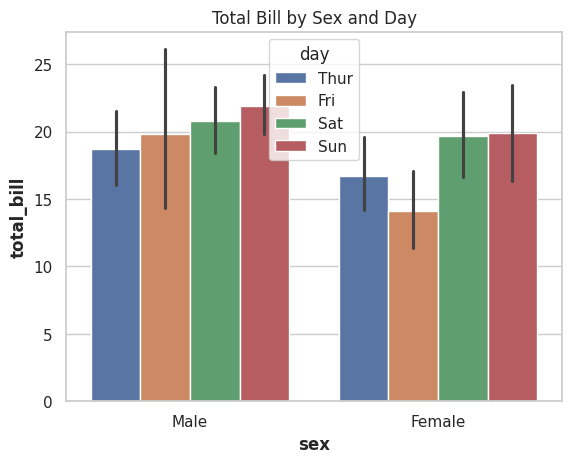

In [185]:
# Clustered Bar Chart for male and female
# Total Bill and Sex and Day

tips = sns.load_dataset("tips")

plt.title("Total Bill by Sex and Day")
sns.barplot(x="sex", y="total_bill", hue="day", data=tips)
plt.show()

### Stacked Bar Chart

A stacked bar plot displays the total value of each category while showing how individual components contribute to that total.
- Each bar represents a category, and each segment within the bar represents a child component, stacked to form the whole.
- It is used to compare both overall totals and part-to-whole contributions across categories.

/tmp/ipython-input-4000525403.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bill_group = tips.groupby(['day', 'sex'])['total_bill'].sum().unstack()


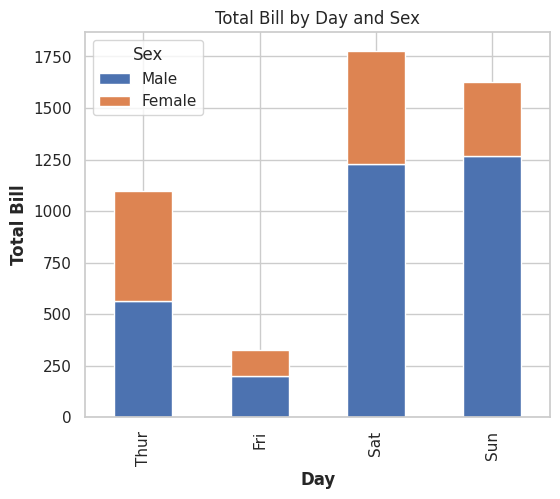

In [186]:
tips = sns.load_dataset("tips")

# Aggregate total bill by day and sex
bill_group = tips.groupby(['day', 'sex'])['total_bill'].sum().unstack()
bill_group.plot(kind='bar',stacked=True,figsize=(6, 5))

plt.title("Total Bill by Day and Sex")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.legend(title="Sex")

plt.show()

- Stacked Bar Plot: Emphasizes composition and total magnitude of each category.
- Clustered Bar Plot: Places bars side-by-side to compare different sub-categories within each main category, rather than their contribution to a whole.

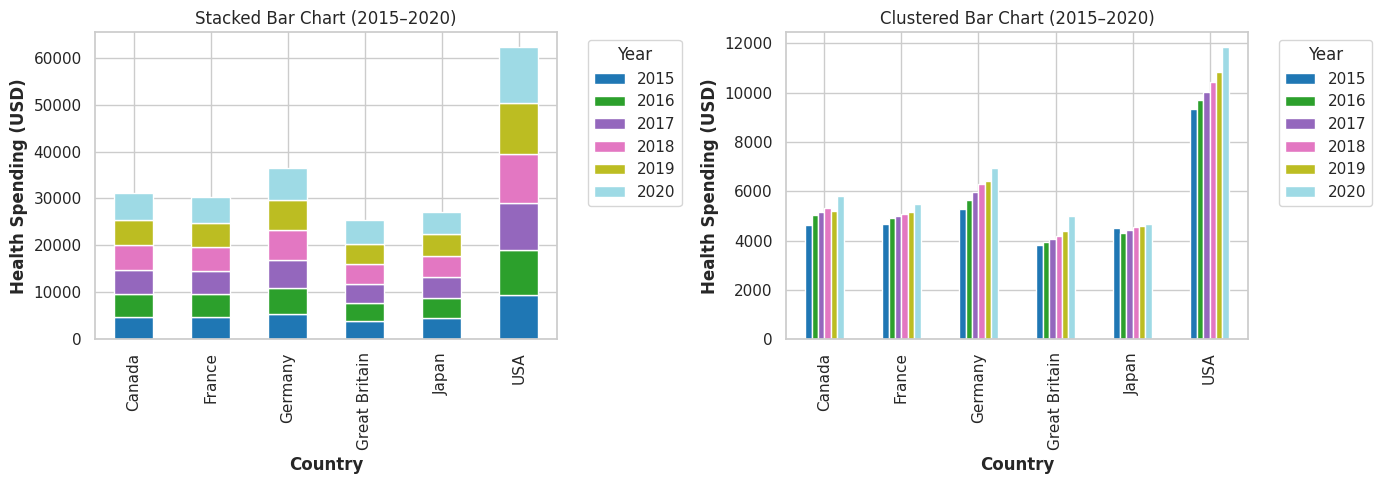

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
health = sns.load_dataset("healthexp")

# Filter for years 2015–2020
health = health[(health["Year"] >= 2015) & (health["Year"] <= 2020)]

# Group data
health_group = (
    health.groupby(["Country", "Year"])["Spending_USD"]
    .sum()
    .unstack()
)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked Bar Chart
health_group.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    colormap="tab20"
)
axes[0].set_title("Stacked Bar Chart (2015–2020)")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Health Spending (USD)")
axes[0].legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")

# Clustered (Grouped) Bar Chart
health_group.plot(
    kind="bar",
    stacked=False,
    ax=axes[1],
    colormap="tab20"
)
axes[1].set_title("Clustered Bar Chart (2015–2020)")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Health Spending (USD)")
axes[1].legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Pareto Chart

A Pareto Chart is a visualization that identifies the most significant factors by ranking categories from highest to lowest impact. It is a combination of a bar chart and a line chart, where bars show individual values and the line shows the cumulative percentage.

/tmp/ipython-input-4105323183.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pareto_data = (tips.groupby("day")["total_bill"].sum()


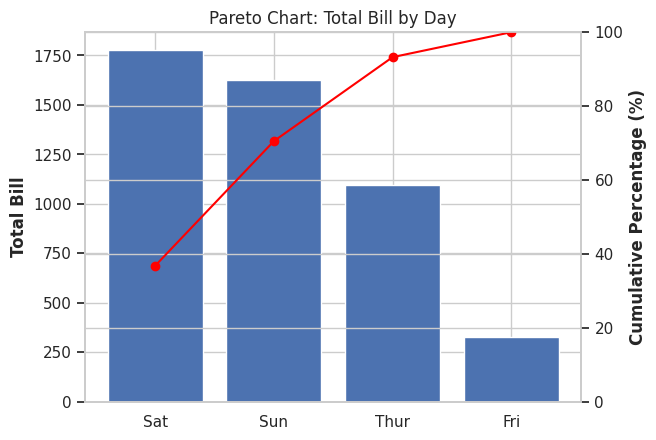

In [188]:
# Patero Chart for Total Bills
tips = sns.load_dataset("tips")

# Aggregate total bill by day
pareto_data = (tips.groupby("day")["total_bill"].sum()
.sort_values(ascending=False))

# Compute cumulative percentage
cumulative_pct = pareto_data.cumsum() / pareto_data.sum() * 100

# Create figure
fig, ax1 = plt.subplots()

# Bar chart (Total Bill)
ax1.bar(pareto_data.index, pareto_data.values)
ax1.set_ylabel("Total Bill")
ax1.set_title("Pareto Chart: Total Bill by Day")

# Line chart (Cumulative Percentage)
ax2 = ax1.twinx()
ax2.plot(pareto_data.index, cumulative_pct, marker="o", color='red')
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 100)

plt.show()

### Point Plot

A point plot displays the mean of a quantitative variable for observations within each category.
- Each category is represented by a single point showing its mean value.
- When multiple categories or groups are present, the mean points are connected by lines to highlight comparisons and trends across categories.

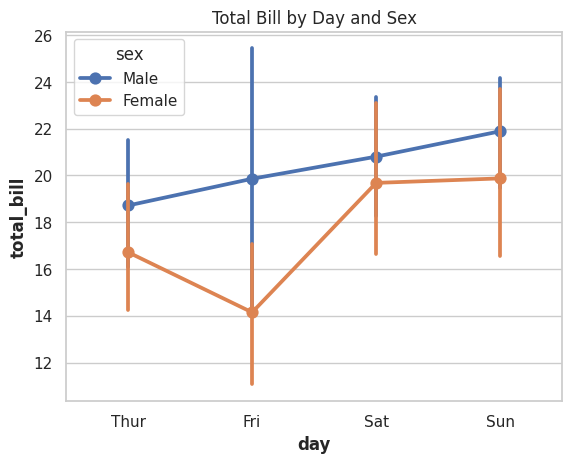

In [189]:
# Point plot for Day per sex

tips = sns.load_dataset("tips")

plt.title("Total Bill by Day and Sex")
sns.pointplot(x="day", y="total_bill", hue="sex", data=tips)
plt.show()

### Line Chart

A chart that visualizes data in the form of data points connected by straight lines, used to track the trend of data fluctuations over time or another continuous interval.

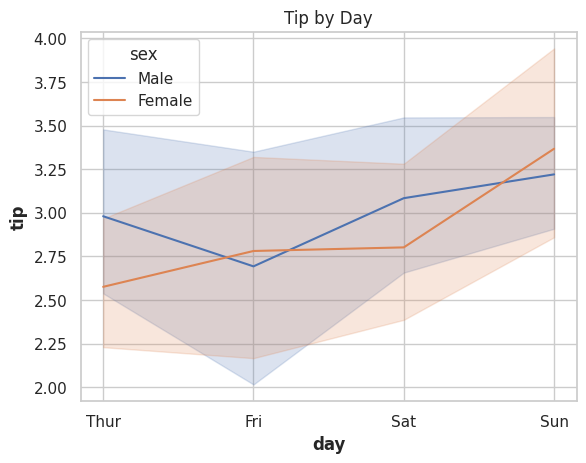

In [190]:
# Line chart for tip
tips = sns.load_dataset("tips")

plt.title("Tip by Day")
sns.lineplot(x="day", y="tip", data=tips, hue='sex')
plt.show()

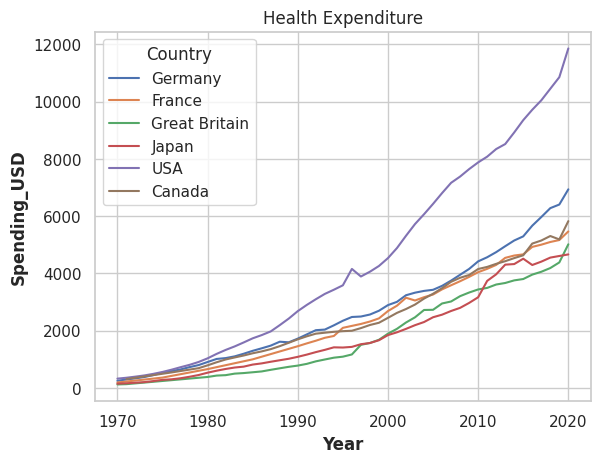

In [191]:
# Simple line chart
health = sns.load_dataset("healthexp")

plt.title('Health Expenditure')
sns.lineplot(x='Year', y='Spending_USD', hue='Country', data=health)
plt.show()

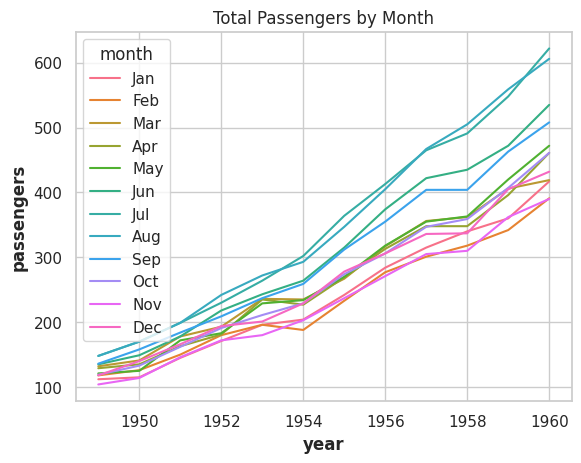

In [192]:
flights = sns.load_dataset("flights")

# Line chart
plt.title("Total Passengers by Month")
sns.lineplot(x="year", y="passengers", hue="month", data=flights)
plt.show()

### Area Chart

A chart represents the structure and development of objects over time or by category, usually in the form of a rectangle or square divided into different domains.
- An area chart is stacked, meaning multiple data series are layered on top of each other to show both the total value and the contribution of each component over time.

/tmp/ipython-input-3824809606.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips_group = tips.groupby(['day', 'sex'])['tip'].sum().unstack()


<Axes: xlabel='day'>

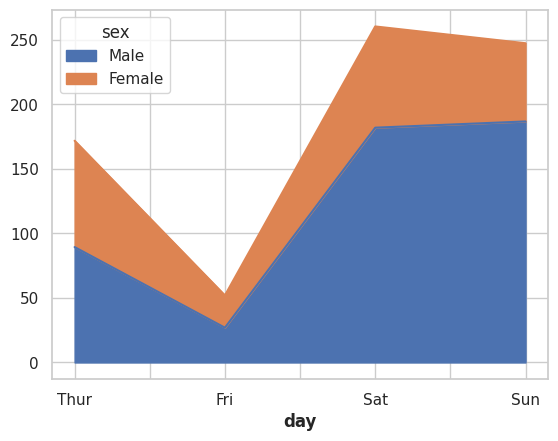

In [193]:
# Area chart for tip
tips = sns.load_dataset("tips")
tips_group = tips.groupby(['day', 'sex'])['tip'].sum().unstack()

tips_group.plot.area()

- Normal Area Chart: Shows absolute values and how they change over time.
- 100% Area Chart: Shows relative proportions, where each category is normalized to 100% at each point in time.

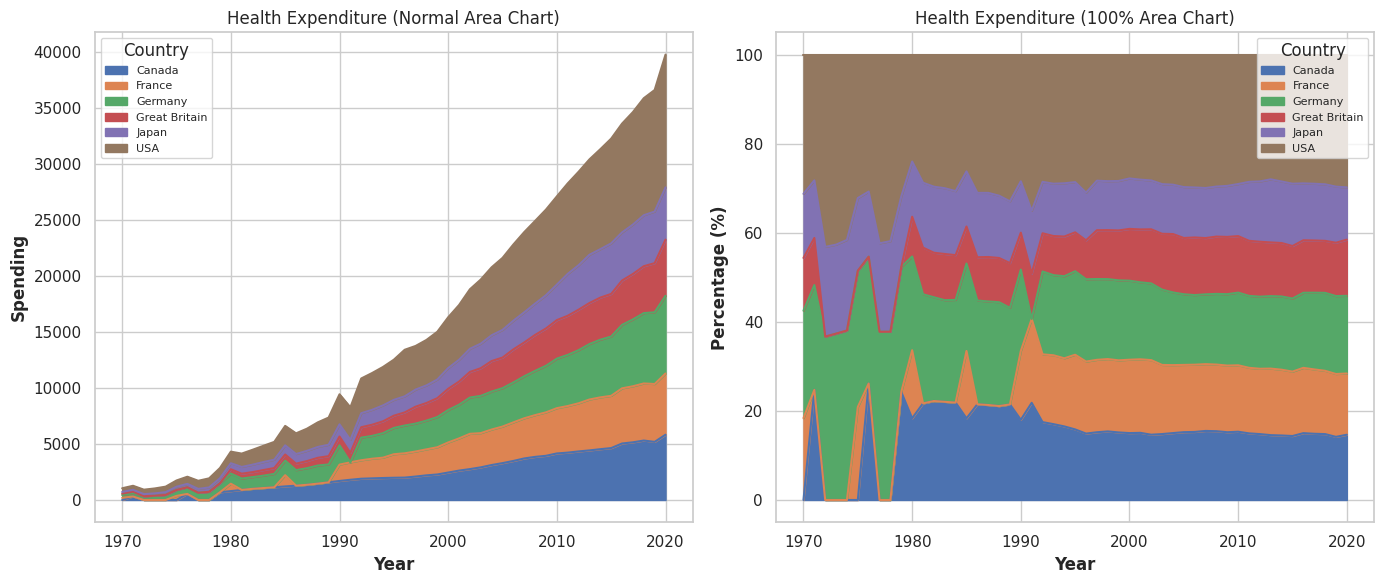

In [194]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
health = sns.load_dataset("healthexp")

# Pivot data for area plotting
pivot = health.pivot(index="Year", columns="Country", values="Spending_USD")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# --- Normal area chart ---
pivot.plot.area(ax=axes[0])
axes[0].set_title("Health Expenditure (Normal Area Chart)")
axes[0].set_ylabel("Spending")
axes[0].legend(title="Country", fontsize=8)

# --- 100% area chart ---
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot.area(ax=axes[1])
axes[1].set_title("Health Expenditure (100% Area Chart)")
axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title="Country", fontsize=8)

plt.tight_layout()
plt.show()


### Step Chart

Displays data as a series of horizontal steps, emphasizing sudden changes or discrete intervals.
- Commonly used for process changes, system states, or pricing models.

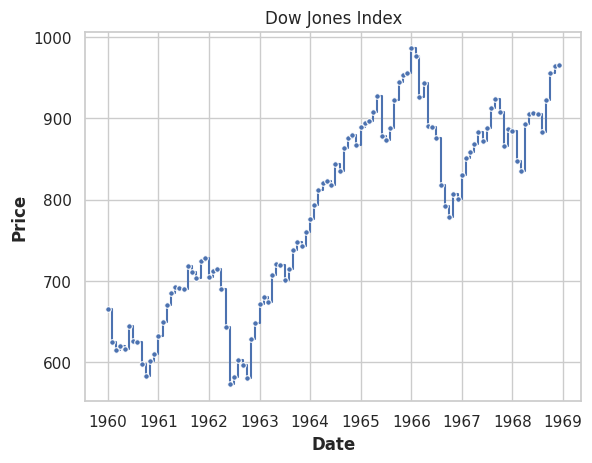

In [195]:
# Step Chart for dowjones
dowjones = sns.load_dataset("dowjones")

# Extract the year as its own column
dowjones['Year'] = pd.to_datetime(dowjones['Date']).dt.year
# Focus on 1965 to 1970
dowjones = dowjones[dowjones['Year'].between(1960, 1971)]
plt.title("Dow Jones Index")
sns.lineplot(x="Date", y="Price", data=dowjones,
             drawstyle='steps-post', marker='o', markersize=4)
plt.show()


### Horizon Chart

A horizon chart is a compact visualization for time-series data that layers values using colors to show magnitude and direction. It is designed to compare multiple time series efficiently, saving space while preserving trend information.

In [196]:
import altair as alt
import pandas as pd

# Sample data
source = pd.DataFrame([
    {"x": 1, "y": 28}, {"x": 2, "y": 55}, {"x": 3, "y": 43}, {"x": 4, "y": 91},
    {"x": 5, "y": 81}, {"x": 6, "y": 53}, {"x": 7, "y": 19}, {"x": 8, "y": 87},
    {"x": 9, "y": 52}, {"x": 10, "y": 48}, {"x": 11, "y": 24}, {"x": 12, "y": 49},
    {"x": 13, "y": 87}, {"x": 14, "y": 66}, {"x": 15, "y": 17}, {"x": 16, "y": 27},
    {"x": 17, "y": 68}, {"x": 18, "y": 16}, {"x": 19, "y": 49}, {"x": 20, "y": 15}
])

band_size = 30  # height of each band

def horizon_band(offset, color):
    return (
        alt.Chart(source)
        .mark_area(interpolate='monotone', opacity=0.7)
        .encode(
            x='x:Q',
            y=alt.Y('y_band:Q', scale=alt.Scale(domain=[0, band_size]), title=None),
            color=alt.value(color)
        )
        .transform_calculate(
            y_band=f"max(datum.y - {offset}, 0)"
        )
    )

# Three bands (low → high)
band1 = horizon_band(0, "steelblue")
band2 = horizon_band(band_size, "seagreen")
band3 = horizon_band(2 * band_size, "firebrick")

chart = (
    band1 + band2 + band3
).properties(
    width=500,
    height=80,
    title="Horizon Chart (3 Density Bands)"
)

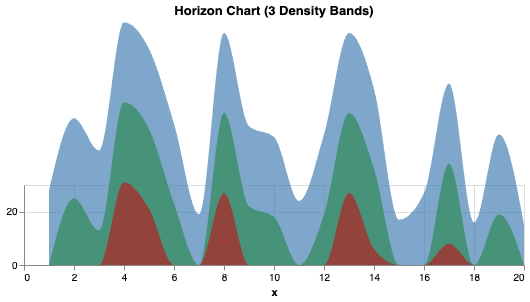

### Candlestick Chart

A financial chart used to show price movement over time. Each candlestick represents open, high, low, and close (OHLC) values, making it ideal for analyzing market trends and volatility.

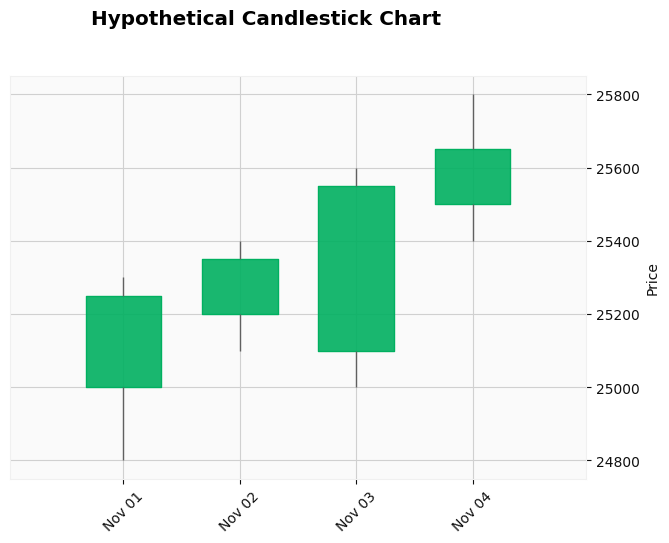

In [197]:
!pip install mplfinance
import mplfinance as mpf
import pandas as pd
import seaborn as sns

# NOTE: The original dowjones dataset has only Date and Price (Close).
# A real candlestick chart requires Open, High, Low, and Close data.
# This example uses a *hypothetical* dataset structure to illustrate the plot:

data = {
    'Date': pd.to_datetime(['2025-11-01', '2025-11-02', '2025-11-03', '2025-11-04']),
    'Open': [25000, 25200, 25100, 25500],
    'High': [25300, 25400, 25600, 25800],
    'Low': [24800, 25100, 25000, 25400],
    'Close': [25250, 25350, 25550, 25650],
    'Volume': [10000, 12000, 15000, 11000]
}
# Create a DataFrame and set Date as the index as required by mplfinance
ohlc_df = pd.DataFrame(data).set_index('Date')

# Plot the candlestick chart
mpf.plot(ohlc_df, type='candle', style='yahoo', title='Hypothetical Candlestick Chart')



### Renko Chart

A chart that focuses purely on price movement. It ignores time intervals and only adds a new "brick" when the price moves by a predefined amount.

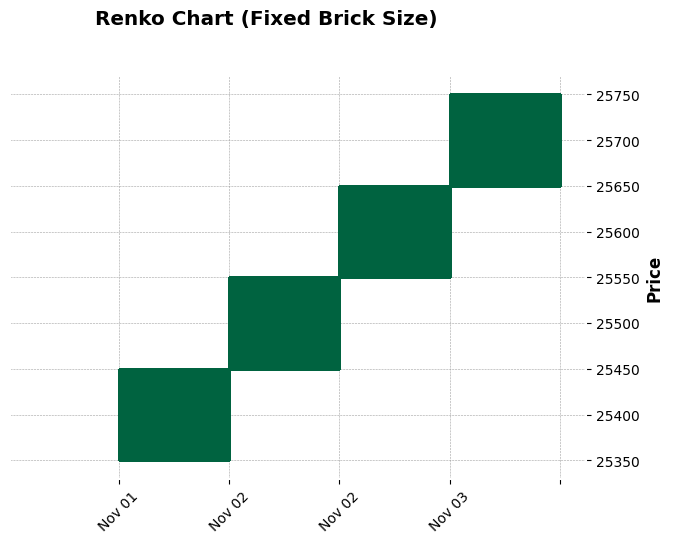

In [198]:
mpf.plot(ohlc_df,
         type='renko',
         renko_params=dict(brick_size=100),
         style='charles',
         title='Renko Chart (Fixed Brick Size)')

### Box Plot

A box plot visualizes the distribution of data using key statistical measures.
- It displays:
the minimum and maximum values (excluding outliers), median, first quartile (Q1), and third quartile (Q3). The interquartile range (IQR = Q3 − Q1) represents the spread of the middle 50% of the data. Outliers are shown as individual points beyond the whiskers

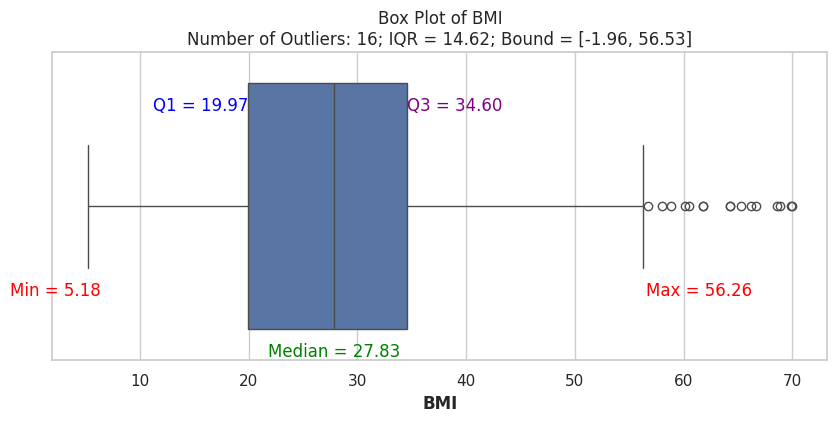

In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn theme
sns.set_theme(style="whitegrid")

# Seed
np.random.seed(42)

# Generate BMI values
bmi_values = np.random.uniform(15, 40, 500)
low_outliers = np.random.uniform(5, 12, 25)
high_outliers = np.random.uniform(45, 70, 25)
all_bmi = np.concatenate([bmi_values, low_outliers, high_outliers])
df = pd.DataFrame({"BMI": all_bmi})

# Quantiles and IQR
Q1 = df['BMI'].quantile(0.25)
Q2 = df['BMI'].median()
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

outliers_bmi = df[(df['BMI'] < LB) | (df['BMI'] > UB)]
num_outliers_bmi = len(outliers_bmi)

# Get the max and min without outliers
max_without_outliers = df[(df['BMI'] >= LB) & (df['BMI'] <= UB)]['BMI'].max()
min_without_outliers = df[(df['BMI'] >= LB) & (df['BMI'] <= UB)]['BMI'].min()

# Single figure & axis
fig, ax = plt.subplots(figsize=(10, 4))  # wider for horizontal

# Horizontal boxplot
sns.boxplot(x=df["BMI"], ax=ax)

# Annotations (adjust for horizontal)
ax.text(Q1, -0.3, f'Q1 = {Q1:.2f}', color='blue', va='bottom', ha='right')
ax.text(Q2, 0.5, f'Median = {Q2:.2f}', color='green', va='bottom', ha='center')
ax.text(Q3, -0.3, f'Q3 = {Q3:.2f}', color='purple', va='bottom', ha='left')
ax.text(LB, 0.3, f'Min = {min_without_outliers:.2f}', color='red', va='bottom', ha='left')
ax.text(UB, 0.3, f'Max = {max_without_outliers:.2f}', color='red', va='bottom', ha='left')

# Title
ax.set_title(f'Box Plot of BMI\nNumber of Outliers: {num_outliers_bmi}; IQR = {IQR:.2f}; Bound = [{LB:.2f}, {UB:.2f}]')
plt.show()

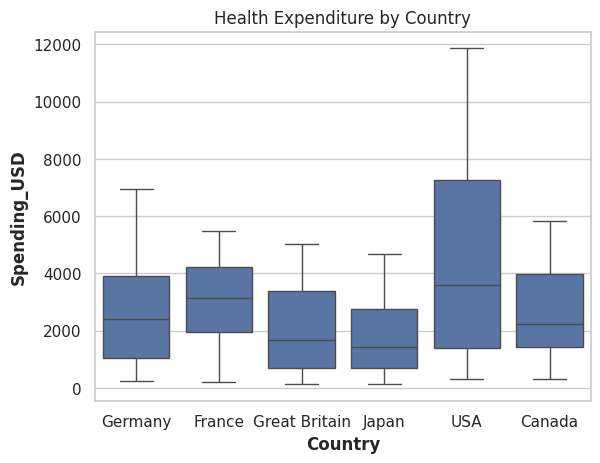

In [200]:
# Box plot of Health by Country
health = sns.load_dataset("healthexp")

plt.title("Health Expenditure by Country")
sns.boxplot(x="Country", y="Spending_USD", data=health)
plt.show()

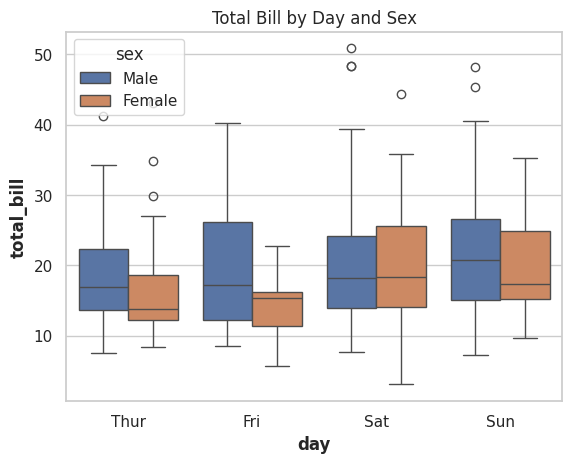

In [201]:
# Box plot of Total Bills for Male and Female
tips = sns.load_dataset("tips")

plt.title("Total Bill by Day and Sex")
sns.boxplot(x="day", y="total_bill", hue='sex', data=tips)
plt.show()

### Violin Plot

Quite similar to a Box Plot, but it also shows the full distribution shape of the data.
- Combines a box plot summary (median and quartiles) with a kernel density estimation, revealing how values are concentrated.
- Useful for comparing distributions across categories, especially when understanding data density and multimodality is important.

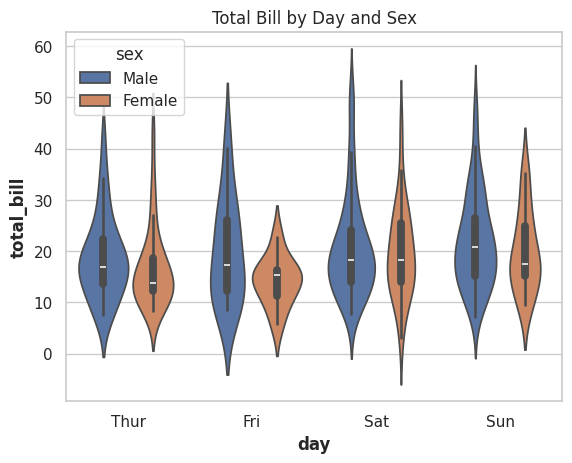

In [202]:
# Violin plot of Total Bills for Male and Female
# The violin-shaped area represents the probability density of the data.
tips = sns.load_dataset("tips")

plt.title("Total Bill by Day and Sex")
sns.violinplot(x="day", y="total_bill", hue='sex', data=tips)
plt.show()

### Strip Plot

Displays individual data points for each category along an axis.
- Points may overlap when many observations have similar values.
- Jitter (small random horizontal shifts) is often added to reduce overlap and make the distribution easier to see.

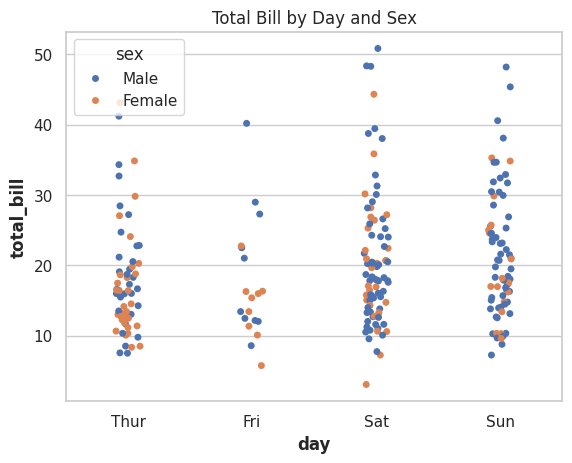

In [203]:
# Strip Plot
tips = sns.load_dataset("tips")

plt.title("Total Bill by Day and Sex")
sns.stripplot(x="day", y="total_bill", hue='sex', data=tips, jitter=True)
plt.show()

### Swarm Plot


Similar to a strip plot but automatically arranges points to avoid overlap.
- It provides a clearer view of the data distribution and density for each category.
- Best used with small to medium-sized datasets due to its layout complexity

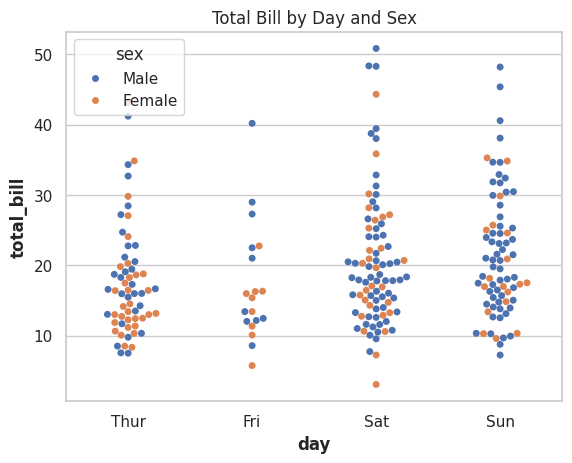

In [204]:
# Swarm Plot
tips = sns.load_dataset("tips")

plt.title("Total Bill by Day and Sex")
sns.swarmplot(x="day", y="total_bill", hue='sex', data=tips)
plt.show()

### Histogram

A histogram shows the distribution of a continuous dataset using vertical bars, where bar width represents data intervals (bins) and bar height indicates frequency.
- Reveals underlying patterns such as skewness, modality, and normal distribution, often visualized as a bell-shaped curve.

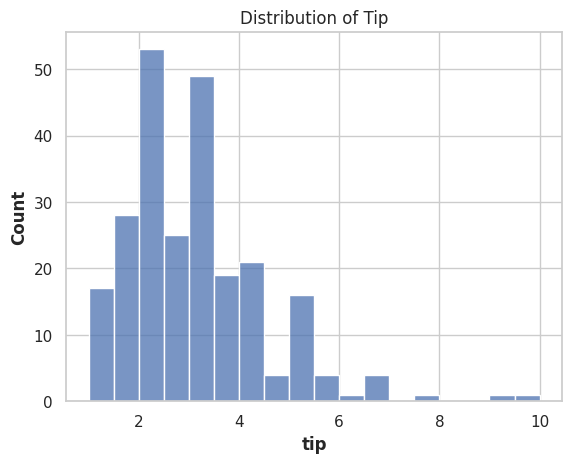

In [205]:
# Distribution of tip
tips = sns.load_dataset("tips")

plt.title("Distribution of Tip")
sns.histplot(tips['tip'])
plt.show()

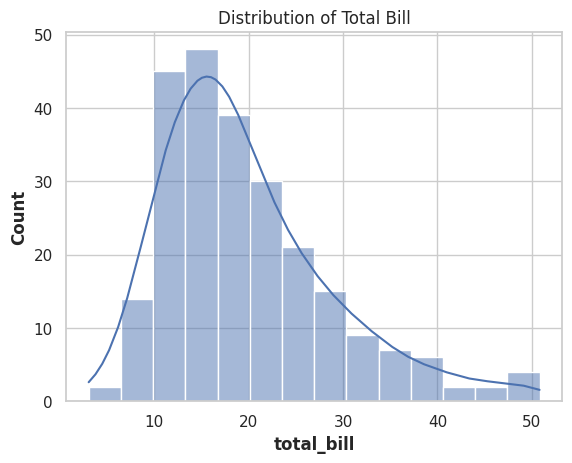

In [206]:
# Distribution of total_bill
tips = sns.load_dataset("tips")

plt.title("Distribution of Total Bill")
sns.histplot(tips['total_bill'], kde=True)
plt.show()

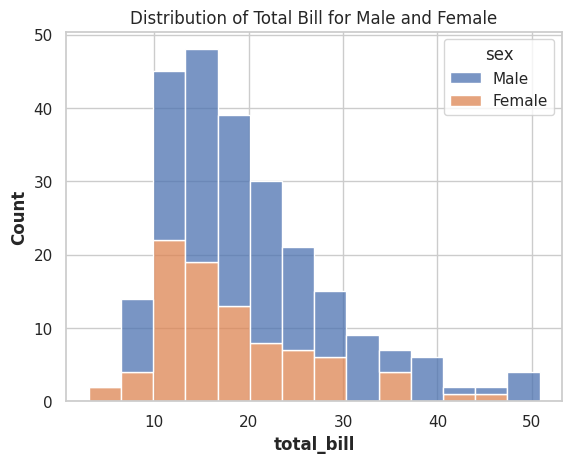

In [207]:
# Distribution of total_bill for male and female
tips = sns.load_dataset("tips")

plt.title("Distribution of Total Bill for Male and Female")
sns.histplot(data=tips, x="total_bill", hue="sex", multiple="stack")
plt.show()

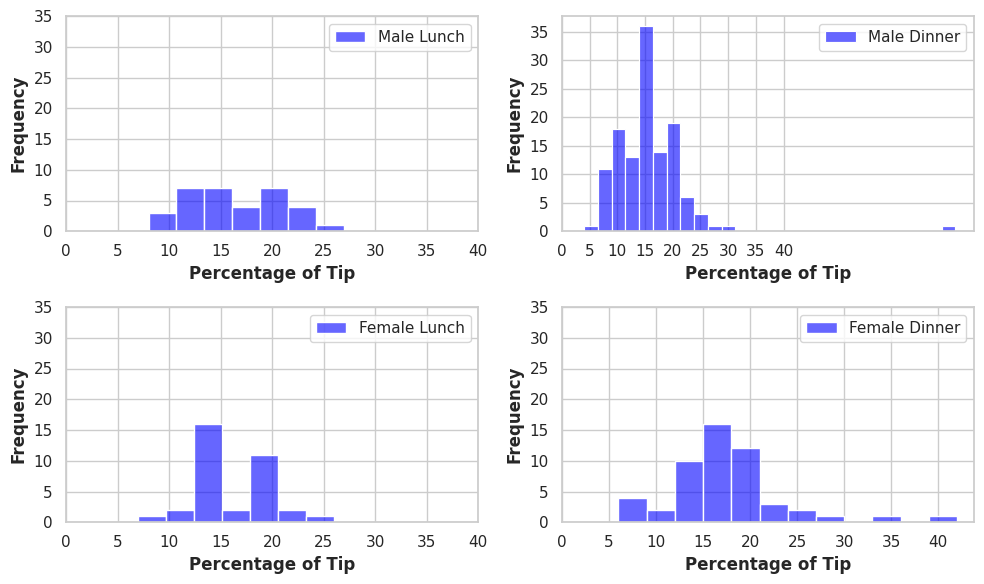

In [208]:
# Histogram
# Calculate tips percentage
tips['percentage_tip'] = round((tips['tip'] / tips['total_bill']) * 100)

# Filter data by gender and time (Lunch/Dinner)
male_lunch_tips = tips[(tips['sex'] == 'Male') & (tips['time'] == 'Lunch')]
female_lunch_tips = tips[(tips['sex'] == 'Female') & (tips['time'] == 'Lunch')]
male_dinner_tips = tips[(tips['sex'] == 'Male') & (tips['time'] == 'Dinner')]
female_dinner_tips = tips[(tips['sex'] == 'Female') & (tips['time'] == 'Dinner')]

# Create a figure with 2x2 subplots (4 histograms)
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
# Set common Y-axis ticks
yticks = np.arange(0, 36, 5)
xticks = np.arange(0, 41, 5)
# Plot for male lunch tips
sns.histplot(male_lunch_tips['percentage_tip'], color='blue', ax=axes[0, 0],
             label='Male Lunch', alpha=0.6)
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_yticks(yticks)
axes[0, 0].set_xticks(xticks)
axes[0, 0].legend()

# Plot for female lunch tips
sns.histplot(female_lunch_tips['percentage_tip'], color='blue', ax=axes[1, 0],
             label='Female Lunch', alpha=0.6)
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_yticks(yticks)
axes[1, 0].set_xticks(xticks)
axes[1, 0].legend()

# Plot for male dinner tips
sns.histplot(male_dinner_tips['percentage_tip'], color='blue', ax=axes[0, 1],
             label='Male Dinner', alpha=0.6)
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yticks(yticks)
axes[0, 1].set_xticks(xticks)
axes[0, 1].legend()

# Plot for female dinner tips
sns.histplot(female_dinner_tips['percentage_tip'], color='blue', ax=axes[1, 1],
             label='Female Dinner', alpha=0.6)
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_yticks(yticks)
axes[1, 1].set_xticks(xticks)
axes[1, 1].legend()

# Set common x-labels
for ax in axes.flat:
    ax.set_xlabel('Percentage of Tip')

# Adjust layout for better visualization
plt.tight_layout()

# Show plot
plt.show()

### KDE Plot
A histogram shows the distribution of a continuous dataset using vertical bars, where bar width represents data intervals (bins) and bar height indicates frequency.
- Reveals underlying patterns such as skewness, modality, and normal distribution, often visualized as a bell-shaped curve.

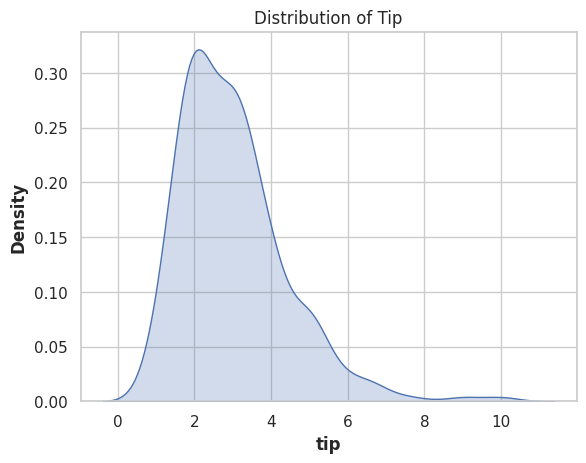

In [209]:
# KDE Plot for Tips
tips = sns.load_dataset("tips")

plt.title("Distribution of Tip")
sns.kdeplot(tips['tip'], fill=True)
plt.show()

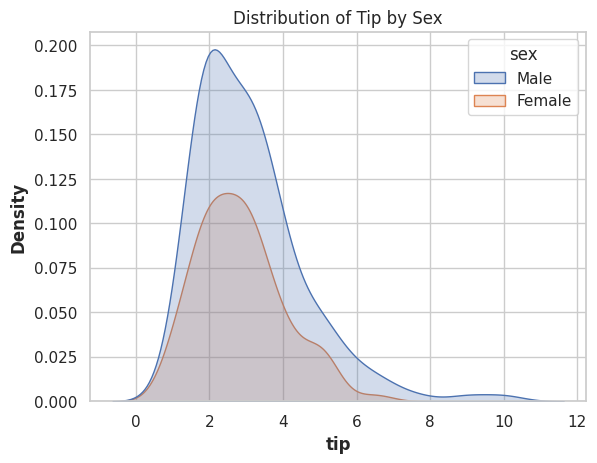

In [210]:
# KDE plot for tips by day
tips = sns.load_dataset("tips")

plt.title("Distribution of Tip by Sex")
sns.kdeplot(data=tips, x="tip", hue="sex", fill=True)
plt.show()

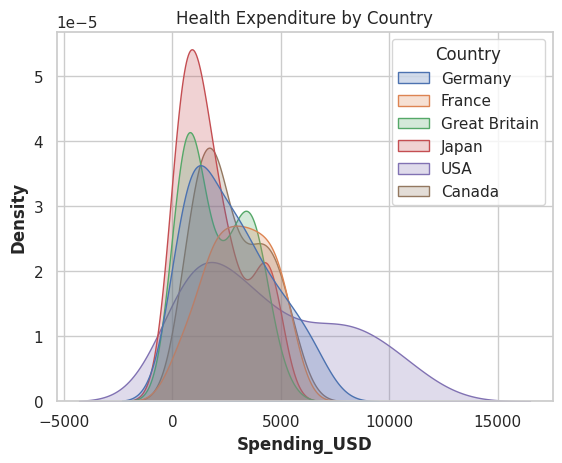

In [211]:
# KDE plot for healthexp by country
health = sns.load_dataset("healthexp")
plt.title("Health Expenditure by Country")
sns.kdeplot(data=health, x="Spending_USD", hue="Country", fill=True)
plt.show()

### Rug Plot

A rug plot shows the distribution of individual data points along an axis using small tick marks. It is often combined with histograms or KDE plots to provide additional detail about data density and exact value locations.

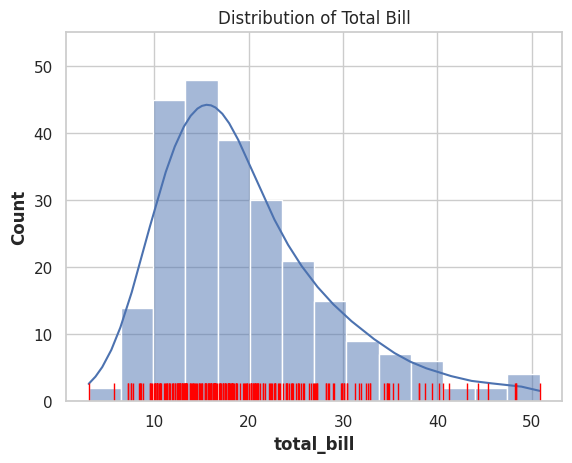

In [212]:
# Distribution of total_bill
tips = sns.load_dataset("tips")

plt.title("Distribution of Total Bill")
sns.histplot(tips['total_bill'], kde=True)
sns.rugplot(tips['total_bill'], height=0.05, color='red')
plt.show()

### ECDF Plot

An ECDF (Empirical Cumulative Distribution Function) plot shows the cumulative proportion of data points less than or equal to a given value. It visualizes the progress toward probability 1.0 (100%) as more observations are included, moving step-by-step from the smallest to the largest value in the dataset.

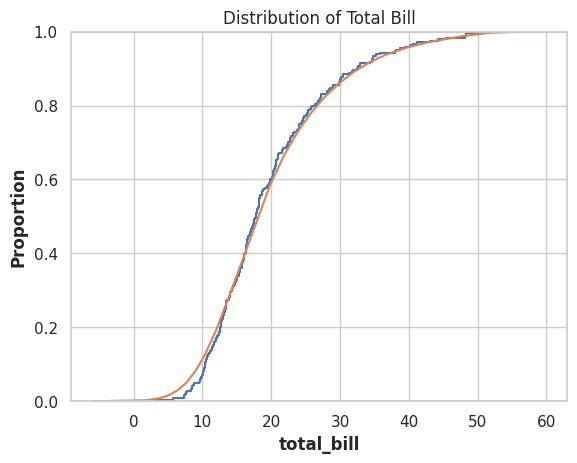

In [213]:
# ECDF Plot
tips = sns.load_dataset("tips")

plt.title("Distribution of Total Bill")
sns.ecdfplot(tips['total_bill'])
# Compare with CDF
sns.kdeplot(tips['total_bill'], cumulative=True)
plt.show()

- **Q–Q (Quantile–Quantile) Plot**: compares the quantiles of a dataset with a theoretical distribution to assess how well the data follows that distribution.
- **P–P (Probability–Probability) Plot**: compares the cumulative probabilities of a dataset with those of a theoretical distribution to evaluate how well the data fits the distribution.

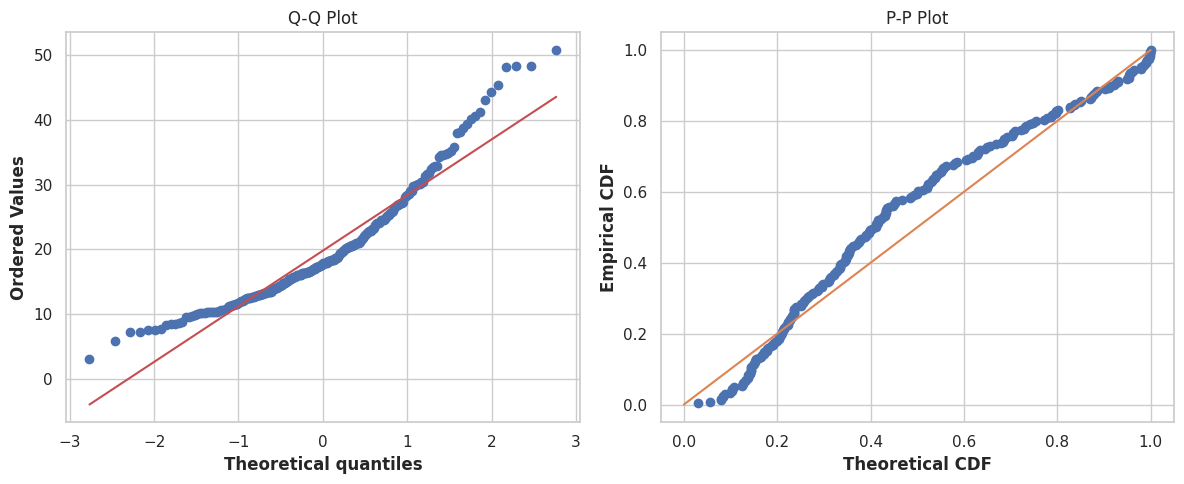

In [214]:
## Q-Q PLot
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Load sample data from seaborn
df = sns.load_dataset("tips")
data = df["total_bill"]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q Plot
stats.probplot(data, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot")

# P-P Plot
# Compute empirical CDF
sorted_data = np.sort(data)
ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Compute theoretical CDF
theoretical_cdf = stats.norm.cdf(sorted_data, np.mean(data), np.std(data))

axes[1].plot(theoretical_cdf, ecdf, marker='o', linestyle='')
axes[1].plot([0, 1], [0, 1])  # Reference line
axes[1].set_title("P-P Plot")
axes[1].set_xlabel("Theoretical CDF")
axes[1].set_ylabel("Empirical CDF")

plt.tight_layout()
plt.show()

### Scatter Plot

This is a chart used to visualize the relationships between two variables, helping to determine the correlation in a data set.

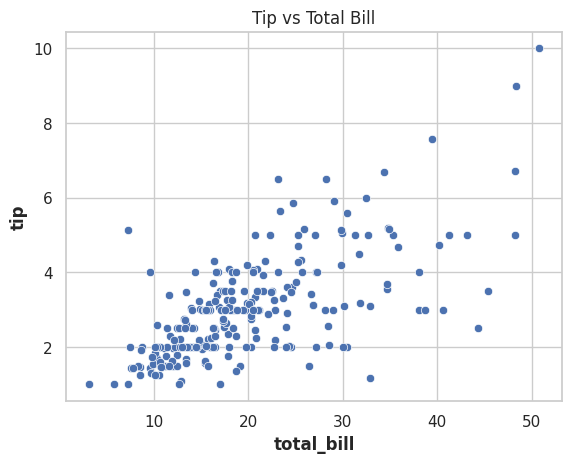

In [215]:
# Scatter Plot of tip and total bills
tips = sns.load_dataset("tips")
plt.title("Tip vs Total Bill")
sns.scatterplot(x="total_bill", y="tip", data=tips)
plt.show()

### Regression Plot

A regression plot extends a scatter plot by adding a regression line defined by
𝒀 = 𝑨 + 𝑩𝑿, where 𝑨 is the intercept and 𝑩 is the slope, showing the overall trend between the variables.

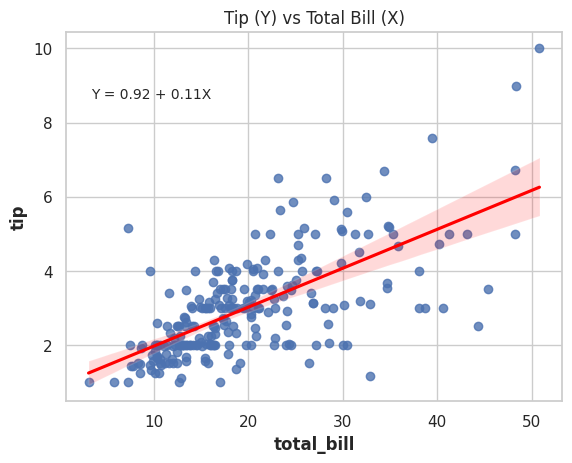

In [216]:
tips = sns.load_dataset("tips")
# Fit linear regression: Y = A + BX
# B = slope, A = intercept
B, A = np.polyfit(tips["total_bill"], tips["tip"], 1)

plt.title("Tip (Y) vs Total Bill (X)")
# Regression line is red
sns.regplot(x="total_bill", y="tip", data=tips,
            line_kws={'color': 'red'})
# Add equation text to the plot
plt.text(0.05, 0.85, f"Y = {A:.2f} + {B:.2f}X",
    transform=plt.gca().transAxes, fontsize=10,
    verticalalignment='top')
# Show the regression equation
plt.show()

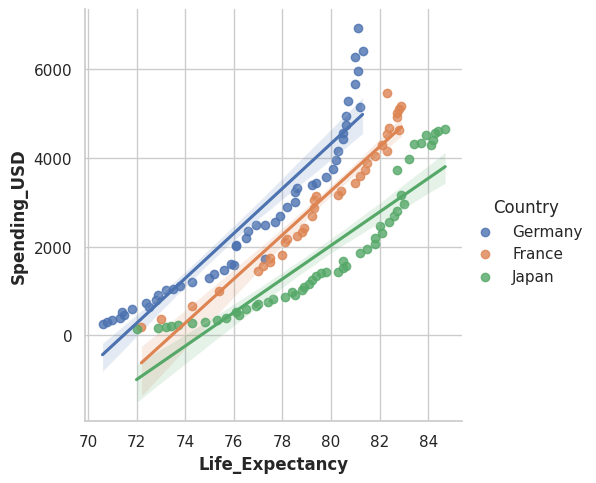

In [217]:
health = sns.load_dataset("healthexp")
health = health[health['Country'].isin(['Germany', 'France', 'Japan'])]

# Regression Plot
sns.lmplot(x="Life_Expectancy", y="Spending_USD", hue='Country', data=health)

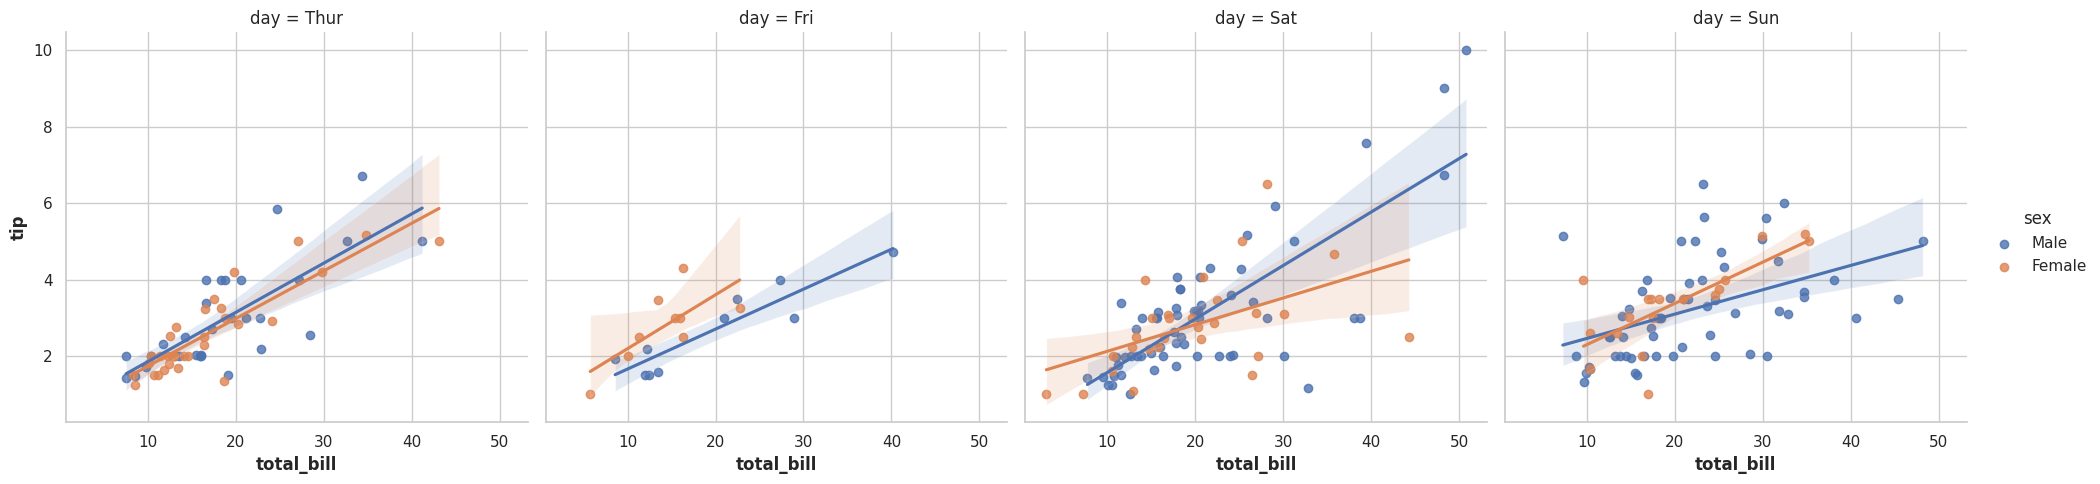

In [218]:
# Male and Female scatter plot based on days
tips = sns.load_dataset("tips")
# Regression Plot
sns.lmplot(x="total_bill", y="tip", data=tips, hue='sex', col='day')

### Heatmap

A heatmap is a two-dimensional visualization that represents the magnitude of values using color intensity.

- It is the most commonly used plot for correlation analysis, where colors indicate the strength and direction of relationships between variables.

- The correlation heatmap is best suited for numerical, continuous, and normalized variables, as it visualizes the strength and direction of relationships between numeric features.


<Axes: >

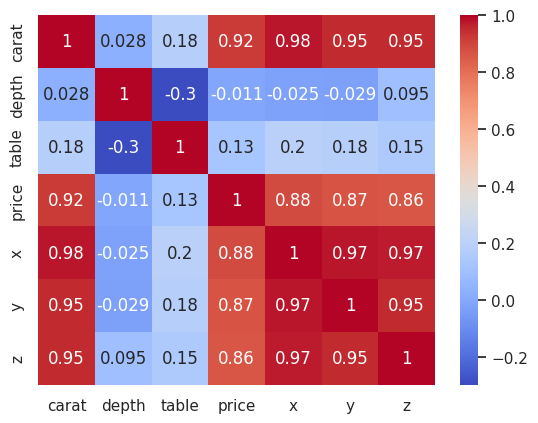

In [219]:
# Heatmap
diamonds = sns.load_dataset("diamonds")
num_cols = diamonds.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(diamonds[num_cols].corr(), annot=True, cmap='coolwarm')

- Heatmaps can also be used to visualize evolution or changes over time, for example showing how values (such as sales, activity, or frequency) vary across time on one axis and categories or locations on the other.

<Axes: xlabel='Year', ylabel='Country'>

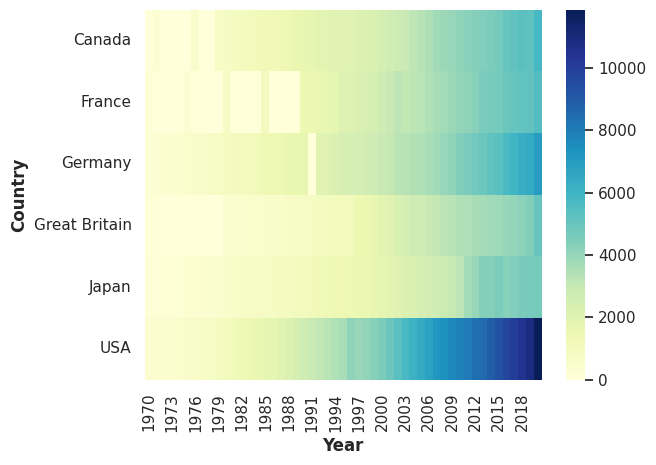

In [220]:
# Heatmaps for evolution
# Spending_USD for each country (Y-Axis) by Year (X-Axis)
health = sns.load_dataset("healthexp")
health_group = health.groupby(['Year', 'Country'])['Spending_USD'].mean()
health_group = health_group.unstack().fillna(0)
sns.heatmap(health_group.T, annot=False, cmap='YlGnBu')

### Pie Chart

A pie chart represents the composition of a whole, where the entire circle equals 100% and each slice shows a component’s percentage.
- Its main drawback is that it only displays proportions, making it unsuitable for precise value comparison or trend analysis.

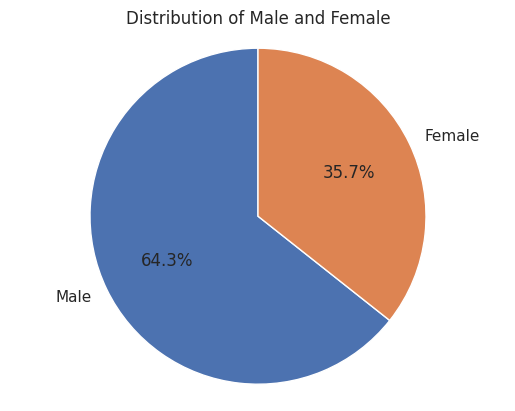

In [221]:
# Pie Chart for Male and Female
tips = sns.load_dataset("tips")

tips_count = tips['sex'].value_counts()
labels = tips_count.index
sizes = tips_count.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Male and Female')
plt.axis('equal')
plt.show()

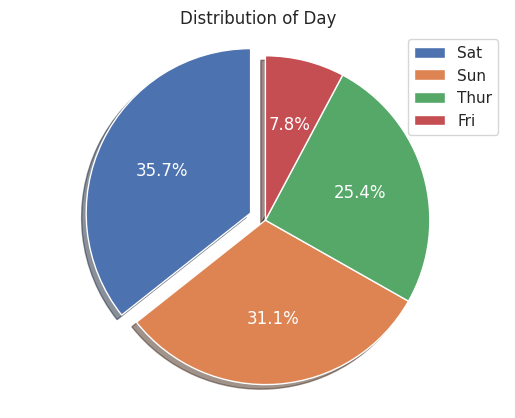

In [223]:
# Pie Chart for Day
tips = sns.load_dataset("tips")

tips_count = tips['day'].value_counts()
labels = tips_count.index
sizes = tips_count.values

# Color of the number is white
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        shadow=True, explode=(0.1, 0, 0, 0),
        textprops={'color': 'white'})
plt.title('Distribution of Day')
plt.legend()
plt.axis('equal')
plt.show()

### Donut Chart

A donut chart is a variation of the pie chart that shows the percentage composition of components within a whole.
- It shares the same limitations as a pie chart, focusing mainly on proportions rather than exact values.
- The center circle can be used to display additional information, such as a total value, key metric, label, or icon, providing extra context.

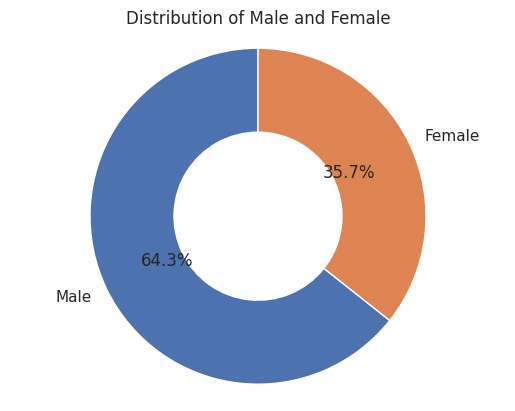

In [230]:
# Donut Chart for Male and Female
tips = sns.load_dataset("tips")

tips_count = tips['sex'].value_counts()
labels = tips_count.index
sizes = tips_count.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        startangle=90, wedgeprops={'width': 0.5})
plt.title('Distribution of Male and Female')
plt.axis('equal')
plt.show()

/tmp/ipython-input-3666950898.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips_group = tips.groupby('day')['tip'].sum()


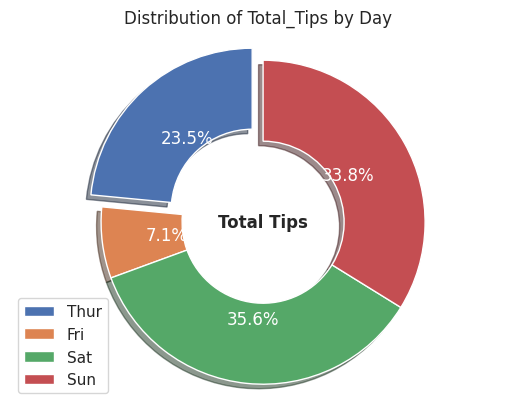

In [237]:
# Donut Chart for Total_Tips per day
tips = sns.load_dataset("tips")

tips_group = tips.groupby('day')['tip'].sum()
labels = tips_group.index
sizes = tips_group

# Color of the number is white
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        shadow=True, explode=(0.1, 0, 0, 0),
        textprops={'color': 'white'}, wedgeprops={'width': 0.5})
plt.title('Distribution of Total_Tips by Day')
plt.text(0, 0, "Total Tips", ha='center', va='center', fontsize=12,
         fontweight='bold')
plt.legend()
plt.axis('equal')
plt.show()

### Sunburst Chart

A sunburst chart is similar to pie and donut charts but represents hierarchical composition, showing how parts break down into sub-parts. It uses concentric rings, where inner rings represent higher-level categories and outer rings show deeper levels of the hierarchy.

In [244]:
# Sunburst Chart
import seaborn as sns
import plotly.express as px

# Load dataset
tips = sns.load_dataset("tips")

# Create sunburst chart
fig = px.sunburst(
    tips,
    path=['day', 'sex', 'time'],   # hierarchy
    values='tip',                  # size by total tips
    title='Sunburst Chart of Tips'
)

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



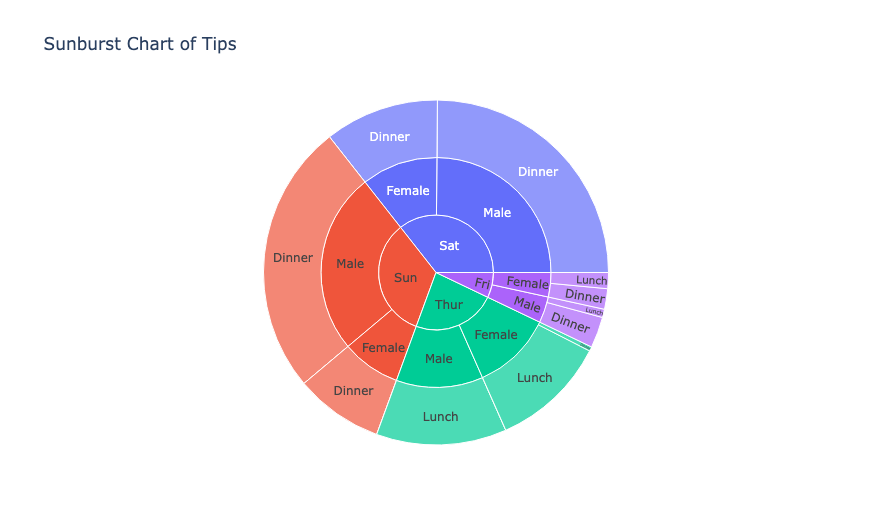

# Combination Plots
Using two or more plots in one figure
- **Bar + Line Graph**: Combines bars and a line to compare individual values (e.g., each country’s spending) with an overall trend or total across the year.

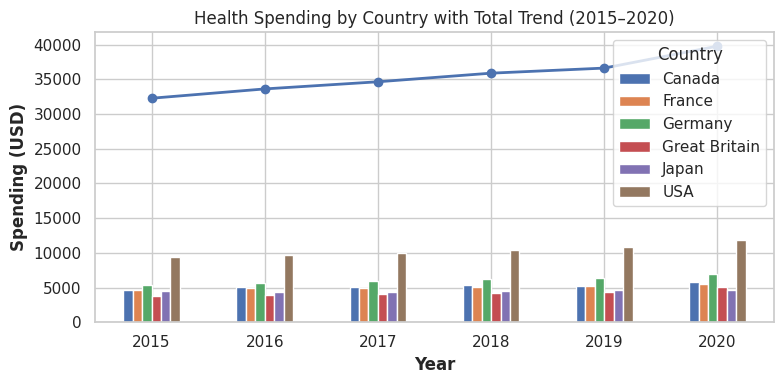

In [260]:
# Load dataset
health = sns.load_dataset("healthexp")
health = df = df[(df["Year"] >= 2015) & (df["Year"] <= 2020)]
# Use a pivot table
pivot_table = df.pivot(index="Year", columns="Country", values="Spending_USD")
# Compute total spending per year for line plot
total_spending = pivot_table.sum(axis=1)

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 4))
# Plot a stacked bar chart
pivot_table.plot(kind="bar", stacked=False, ax=ax)
# Line plot on the SAME axes
ax.plot(range(len(total_spending)), total_spending.values,
        marker="o", linewidth=2)
ax.set_title("Health Spending by Country with Total Trend (2015–2020)")
ax.set_xlabel("Year")
ax.set_ylabel("Spending (USD)")
ax.set_xticks(range(len(total_spending)))
ax.set_xticklabels(total_spending.index, rotation=0)

plt.tight_layout()
plt.show()

- **Histogram + Line Graph**: Combines a histogram with a line (often KDE or trend line) to relate frequency distributions (e.g., rainfall frequency) with a continuous variable such as temperature.

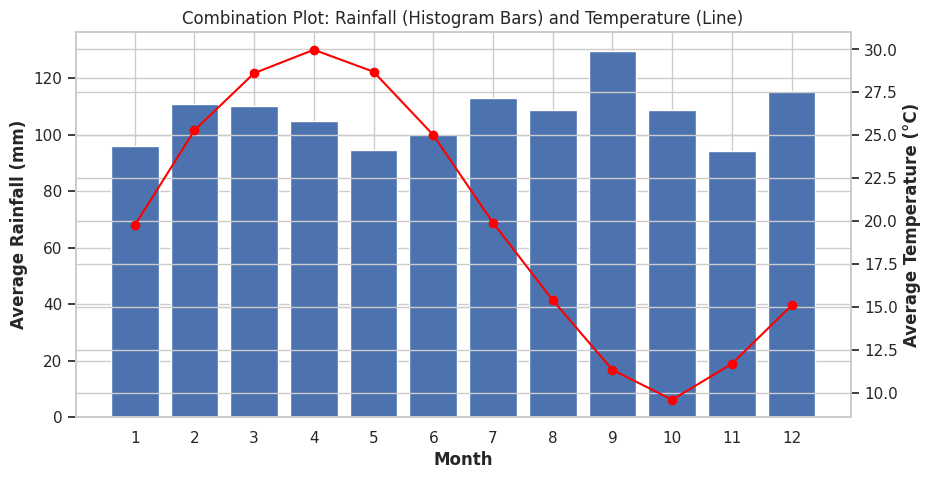

In [265]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Generate random data
n_samples = 500
months = np.random.randint(1, 13, size=n_samples)

# Rainfall (mm): positively skewed
rainfall = np.random.gamma(shape=2.0, scale=50, size=n_samples)

# Temperature (°C): seasonal pattern
temperature = 20 + 10 * np.sin((months - 1) * 2 * np.pi / 12) + np.random.normal(0, 2, n_samples)

# Aggregate rainfall by month (mean)
monthly_rainfall = [rainfall[months == m].mean() for m in range(1, 13)]
monthly_temperature = [temperature[months == m].mean() for m in range(1, 13)]

# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar plot for rainfall
ax1.bar(range(1, 13), monthly_rainfall)
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Rainfall (mm)")
ax1.set_xticks(range(1, 13))

# Second axis for temperature
ax2 = ax1.twinx()
ax2.plot(range(1, 13), monthly_temperature, marker='o', color='red')
ax2.set_ylabel("Average Temperature (°C)")

# Title
plt.title("Combination Plot: Rainfall (Histogram Bars) and Temperature (Line)")

plt.show()

### Joint Plot

A joint plot shows the relationship between two variables using a central plot (such as scatter or hex) along with their individual distributions on the axes. It helps analyze both bivariate relationships and univariate distributions simultaneously.

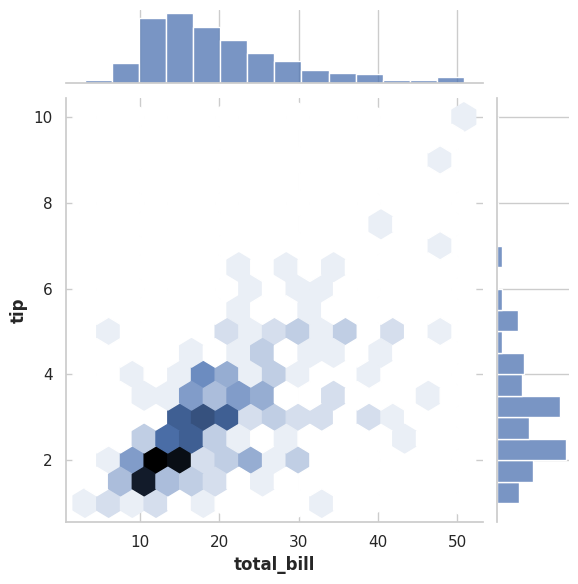

In [266]:
# Joint Plot
tips = sns.load_dataset("tips")
# A joint plot for total bills
sns.jointplot(x="total_bill", y="tip", data=tips, kind="hex")
plt.show()

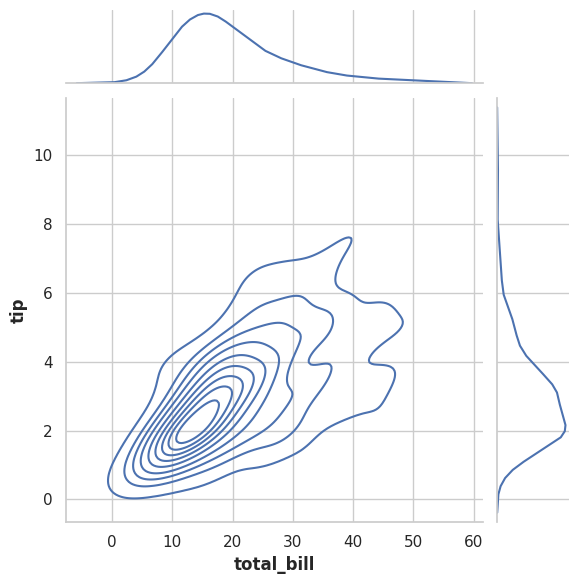

In [267]:
# Use KDE in the joint plot
sns.jointplot(x="total_bill", y="tip", data=tips, kind="kde")
plt.show()

### Choropleth Map

A choropleth map is a geospatial visualization that uses color intensity to represent the magnitude of a variable across geographic regions (countries, states, provinces).

Dataset: https://www.kaggle.com/datasets/hserdaraltan/countries-by-continent?resource=download

In [282]:
import plotly.express as px
import pandas as pd
import numpy as np

# Load the country dataset
df_countries = pd.read_csv('Countries by continents.csv')

# Generate random sales for each country
df_countries['Country_Sales'] = np.random.randint(100, 1000, size=len(df_countries))

# Group by continent to get total sales per continent
continent_sales = df_countries.groupby('Continent', as_index=False)['Country_Sales'].sum()
continent_sales.rename(columns={'Country_Sales': 'Continent_Total_Sales'},
                       inplace=True)

# Merge continent_sales back to the original dataframe
df_merged = pd.merge(df_countries, continent_sales, on='Continent', how='left')

# Create choropleth map
# Locations will be countries, but color will reflect the continent's total sales
fig = px.choropleth(
    df_merged,
    locations='Country',
    locationmode='country names',
    color='Continent_Total_Sales', # Color countries
    # based on their continent's total sales
    hover_name='Country',
    hover_data=['Continent', 'Country_Sales', 'Continent_Total_Sales'],
    title='Total Sales by Continent (represented by country coloring)',
    color_continuous_scale=px.colors.sequential.Plasma
)

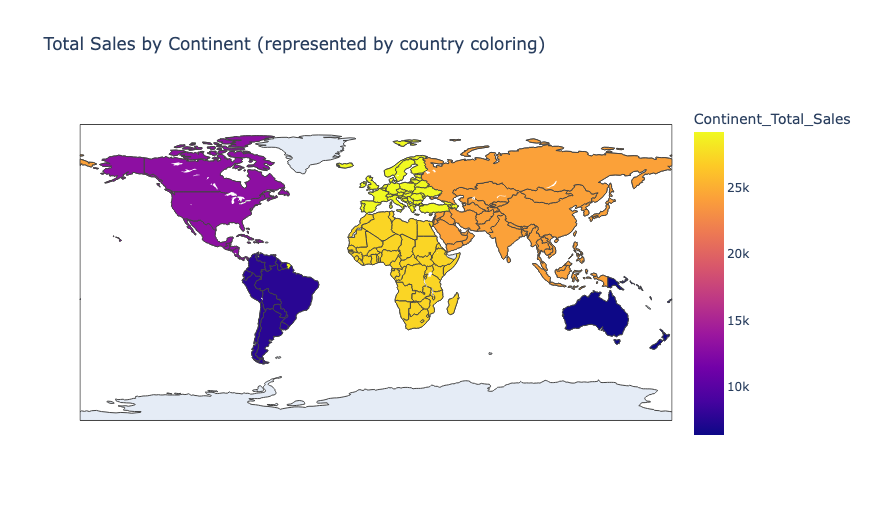

### Gauge Indicator

In [300]:
import plotly.graph_objects as go

health = sns.load_dataset("healthexp")
health = health[health['Country'] == 'USA']
# Is the spending of USA throughout the year surpasses 300,000?
sum_spending = health['Spending_USD'].sum()


# Total spending
sum_spending = health['Spending_USD'].sum()
target = 300000

# Gauge Indicator
fig = go.Figure(go.Indicator(
    mode="gauge+number+delta",
    value=sum_spending,
    delta={'reference': target},
    title={"text": "USA Total Health Spending"},
    gauge={
        "axis": {"range": [0, target]},
        "threshold": {
            "line": {"color": "red", "width": 4},
            "thickness": 0.75,
            "value": target
        },
        "steps": [
            {"range": [0, target], "color": "lightgray"},
            {"range": [target - 50000, target], "color": "lightgreen"}
        ]
    }
))

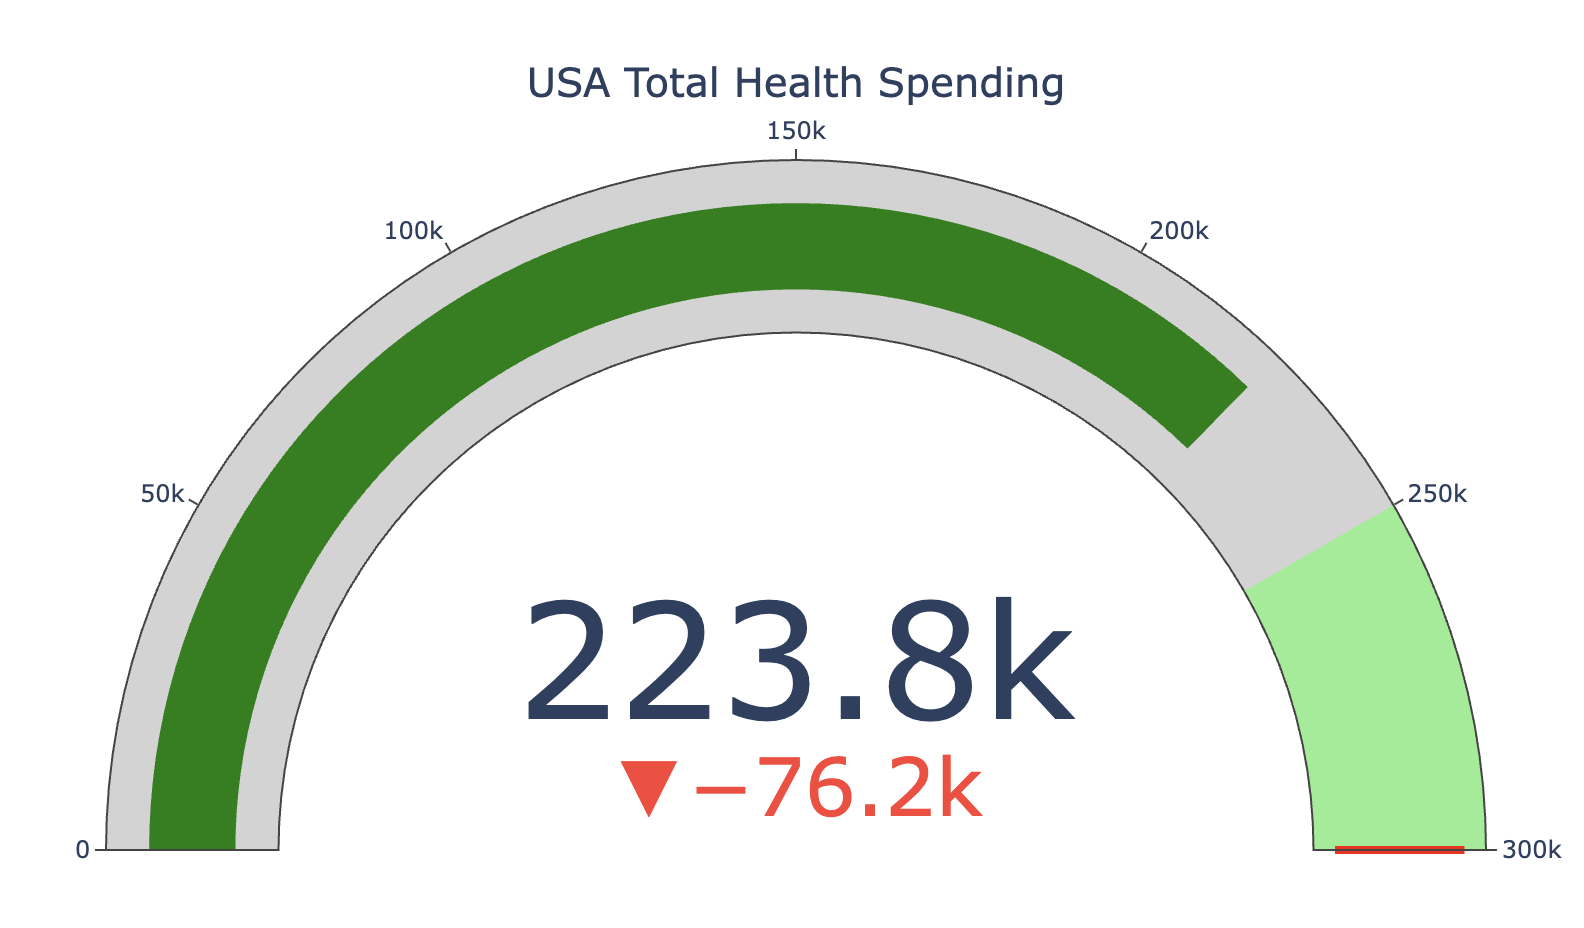